In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_excel('/content/yahoo-finance-stock-data.xlsx')

In [3]:
corr_matrices = df.corr(numeric_only= True)
print(corr_matrices)

              Unnamed: 0  price_usd    change  volume_M  market_cap_B  pe_ratio
Unnamed: 0      1.000000   0.104801 -0.014874 -0.657753     -0.197490  0.053298
price_usd       0.104801   1.000000 -0.041488  0.027453      0.565686 -0.027999
change         -0.014874  -0.041488  1.000000 -0.037021     -0.021970  0.022357
volume_M       -0.657753   0.027453 -0.037021  1.000000      0.439881  0.041622
market_cap_B   -0.197490   0.565686 -0.021970  0.439881      1.000000 -0.038423
pe_ratio        0.053298  -0.027999  0.022357  0.041622     -0.038423  1.000000


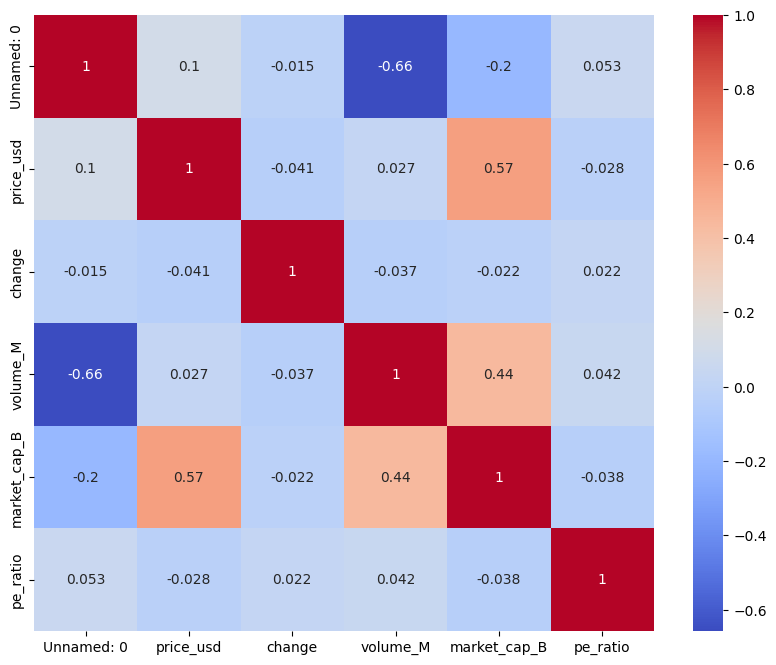

In [4]:
plt.figure(figsize=(10,8))
sb.heatmap(corr_matrices, annot=True, cmap= 'coolwarm')
plt.show()

In [5]:
df = df.drop('Unnamed: 0', axis=1)

In [6]:
df.head()

,name,symbol,price_usd,change,volume_M,market_cap_B,pe_ratio
0,NVIDIA Corporation,NVDA,117.06,3.52,202.631,2856.000,39.82
1,"Lucid Group, Inc.",LCID,2.25,-0.08,135.525,6.863,NaN
2,Alphabet Inc.,GOOGL,151.38,-11.85,127.106,1845.000,16.90
3,Ford Motor Company,F,10.28,-0.16,116.758,40.879,8.22
4,Palantir Technologies Inc.,PLTR,110.48,1.62,95.041,260.723,480.35


In [7]:
df.describe()

,price_usd,change,volume_M,market_cap_B,pe_ratio
count,285.000000,285.000000,285.000000,285.000000,211.000000
mean,51.784632,-0.019789,17.697116,120.671751,52.388341
std,75.213923,2.970610,21.754002,385.929312,128.913607
min,2.250000,-24.350000,5.011000,1.696000,3.040000
25%,10.000000,-0.170000,7.076000,6.317000,12.315000
50%,24.400000,0.040000,10.069000,19.486000,19.690000
75%,66.880000,0.620000,19.053000,66.803000,34.540000
max,596.810000,10.760000,202.631000,3221.000000,1185.330000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          285 non-null    object 
 1   symbol        285 non-null    object 
 2   price_usd     285 non-null    float64
 3   change        285 non-null    float64
 4   volume_M      285 non-null    float64
 5   market_cap_B  285 non-null    float64
 6   pe_ratio      211 non-null    float64
dtypes: float64(5), object(2)
memory usage: 15.7+ KB


In [9]:
df.isnull().sum()

,0
name,0
symbol,0
price_usd,0
change,0
volume_M,0
market_cap_B,0
pe_ratio,74


In [10]:
df['pe_missing'] = df['pe_ratio'].isnull().astype(int)
df['pe_ratio'].fillna(df['pe_ratio'].median(),inplace = True)

/tmp/ipykernel_6701/1264188340.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pe_ratio'].fillna(df['pe_ratio'].median(),inplace = True)


In [11]:
df.isnull().sum()

,0
name,0
symbol,0
price_usd,0
change,0
volume_M,0
market_cap_B,0
pe_ratio,0
pe_missing,0


In [12]:
df.drop_duplicates(inplace = True)

In [13]:
Q1 = df['pe_ratio'].quantile(0.25)
Q3 = df['pe_ratio'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['pe_ratio'] >= Q1 - 1.5 * IQR) & (df['pe_ratio'] <= Q3 + 1.5 * IQR)]

In [14]:
Q1 = df['market_cap_B'].quantile(0.25)
Q3 = df['market_cap_B'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['market_cap_B'] >= Q1 - 1.5 * IQR) & (df['market_cap_B'] <= Q3 + 1.5 * IQR)]

In [15]:
df.drop(columns = ['name','symbol'], inplace=True)

Here are EDA again and the rest

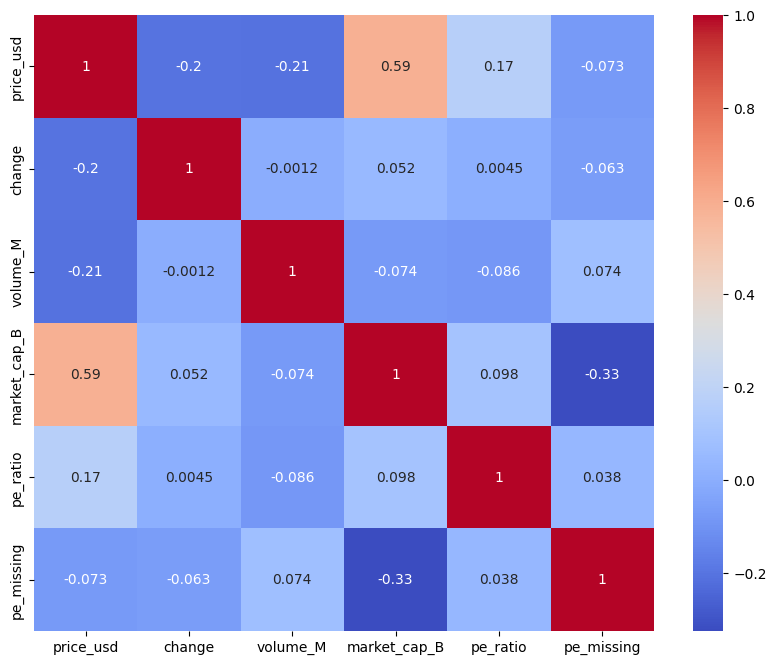

In [16]:
corr_matrices = df.corr(numeric_only= True)
plt.figure(figsize=(10,8))
sb.heatmap(corr_matrices, annot=True, cmap= 'coolwarm')
plt.show()

Rolling statistics mean

In [17]:
df['rolling_mean'] = df['price_usd'].rolling(5).mean()

Rolling Statistics Standard deviasion

In [18]:
df['rolling_std'] = df['price_usd'].rolling(5).std()

RSI

In [19]:
delta = df['price_usd'].diff()
gain = (delta.where(delta > 0 , 0)).rolling(14).mean()
loss = (-delta.where(delta < 0 , 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

MACD

In [20]:
exp1 = df['price_usd'].ewm(span = 12).mean()
exp2 = df['price_usd'].ewm(span = 26).mean()
df['MACD'] = exp1 - exp2
df['Signal'] = df['MACD'].ewm(span = 9).mean()

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(['price_usd', 'Signal'], axis=1)
Y = df['Signal']

x_train, x_test, y_train, y_test = train_test_split(X,Y, shuffle = False)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['price_usd','volume_M','market_cap_B','pe_ratio']] = scaler.fit_transform(
    df[['price_usd','volume_M','market_cap_B','pe_ratio']]
    )

KNN

In [23]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)

combined_train = x_train.join(y_train)
combined_train.dropna(inplace=True)
x_train_cleaned = combined_train.drop(columns=y_train.name)
y_train_cleaned = combined_train[y_train.name]

x_test_cleaned = x_test.dropna()
y_test_cleaned = y_test.loc[x_test_cleaned.index]

model.fit(x_train_cleaned, y_train_cleaned)
y_pred_KNN = model.predict(x_test_cleaned)

Classification for Buy / Sell

In [24]:
df['signal'] = (df['price_usd'].shift(-1) > df['price_usd']).astype(int)

Naive Bayes

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

# Define the classification target Y_clf using the 'signal' column
Y_clf = df['signal']

# Split the data for classification, using the existing features X
# (X was defined in cell jFj2WRcyAN1T as df.drop(['price_usd', 'Signal'], axis=1))
x_train_clf_temp, x_test_clf_temp, y_train_clf, y_test_clf = train_test_split(X, Y_clf, shuffle=False)

# Clean the training data for classification (handling NaNs in features/target)
combined_train_clf = x_train_clf_temp.join(y_train_clf)
combined_train_clf.dropna(inplace=True)
x_train_cleaned_clf = combined_train_clf.drop(columns=y_train_clf.name)
y_train_cleaned_clf = combined_train_clf[y_train_clf.name]

# Clean the testing data for classification
x_test_cleaned_clf = x_test_clf_temp.dropna()
y_test_cleaned_clf = y_test_clf.loc[x_test_cleaned_clf.index]

model = GaussianNB()
model.fit(x_train_cleaned_clf, y_train_cleaned_clf)
y_pred_naiveBayes = model.predict(x_test_cleaned_clf)

Dimensionality reduction with PCA

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 5)
x_train_pca = pca.fit_transform(x_train_cleaned)
x_test_pca = pca.transform(x_test_cleaned)

Ensemble Regressors with Hyperparameter tuning: Random Forest and XGBoost

In [27]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

XGBoost

In [28]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Hyperparameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7]
}
grid =GridSearchCV(RandomForestRegressor() , params, cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [3, 5, 7], 'n_estimators': [100, 200]})

EDA
 ↓
Cleaning
 ↓
Feature Engineering (RSI + MACD)
 ↓
Split Data
 ↓
Models:
   - KNN (Regression)
   - Naive Bayes (Classification)
   - Random Forest / XGBoost
 ↓
PCA
 ↓
Hyperparameter Tuning
 ↓
Evaluation

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    # Use the classification-specific cleaned data
    model.fit(x_train_cleaned_clf , y_train_cleaned_clf)
    y_pred = model.predict(x_test_cleaned_clf)
    acc = accuracy_score(y_test_cleaned_clf, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

KNN Accuracy: 0.6071
Naive Bayes Accuracy: 0.6429
Random Forest Accuracy: 0.6429
XGBoost Accuracy: 0.7143


The highest accuracy is 66.07% for (XGBoost)

1D_CNN_Pattern_Recognition in time series

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D , MaxPooling1D , Flatten , Dense
from tensorflow.keras.optimizers import Adam

model=Sequential([
    Conv1D(32,kernel_size=3,activation='relu',input_shape=(5,1), padding='same'), # Adjusted input_shape and added padding
    MaxPooling1D(pool_size=2), # Output length: ceil(5/2) = 3
    Conv1D(64,kernel_size=3,activation='relu', padding='same'), # Output length: ceil(3/2) = 2
    MaxPooling1D(pool_size=2), # Output length: ceil(2/2) = 1
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 5, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 2, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

Train

In [40]:
model.fit(x_train_pca.reshape(-1, x_train_pca.shape[1], 1), y_train_clf,epochs=20,validation_split=0.2,batch_size=32)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.4754 - loss: 38.6725 - val_accuracy: 0.4194 - val_loss: 103.6677
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5082 - loss: 36.9317 - val_accuracy: 0.4516 - val_loss: 102.1372
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5164 - loss: 33.3829 - val_accuracy: 0.3226 - val_loss: 95.7833
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5082 - loss: 31.3479 - val_accuracy: 0.3548 - val_loss: 87.3451
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5328 - loss: 28.5444 - val_accuracy: 0.3548 - val_loss: 78.1346
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5410 - loss: 25.6954 - val_accuracy: 0.4194 - val_loss: 71.2587
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5246 - loss: 22.8335 - val_accuracy: 0.4516 - val_loss: 67.4809
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5410 - loss: 19.7830 - val_accuracy: 0.4516 -

In [44]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Cropping1D
from tensorflow.keras.models import Model

input_layer = Input(shape=(5,1))

# Encoder
x = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(2, padding='same')(x)

# Decoder
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = UpSampling1D(size=2)(x) # Changed from MaxPooling1D to UpSampling1D
x = Cropping1D(cropping=(0, 1))(x) # Crop to match original input length of 5

output_layer = Conv1D(1, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

In [46]:
X_normal = x_train_pca.reshape(-1, x_train_pca.shape[1], 1)
autoencoder.fit(X_normal, X_normal, epochs=20, batch_size=32)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 572.5930
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 571.7346
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 571.4268
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 569.4238
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 564.3038
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 562.6708 
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 561.8317
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 561.3737
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 561.0057
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 560.4719
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 559.9495 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 559.8519
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 559.7598
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 559.6960
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 559.6369
Ep

In [56]:
X_test_reshaped = x_test_pca.reshape(-1, x_test_pca.shape[1], 1)
reconstructions_test = autoencoder.predict(X_test_reshaped)

# Calculate reconstruction error for the test set
mse_test = np.mean(np.power(X_test_reshaped - reconstructions_test, 2), axis=(1,2))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [57]:
threshold = np.percentile(mse_test, 95)
anomalies = mse_test > threshold

In [53]:
# Freeze early layers
for layer in model.layers[:-2]:
    layer.trainable = False

# Fine-tune
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x_train_pca.reshape(-1, x_train_pca.shape[1], 1), y_train_cleaned_clf, epochs=10)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5686 - loss: 2.2794
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 1.6219 
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6144 - loss: 1.3343 
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 1.2239 
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6078 - loss: 1.1040 
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 1.0248 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6144 - loss: 1.0055 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6536 - loss: 0.9123
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6405 - loss: 0.9453 
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 0.9317 


In [58]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test_clf, mse_test)  # use error as prediction score with binary labels
print("ROC-AUC:", auc)

ROC-AUC: 0.3665389527458493
